# Решение системы Лоренца явными методами Рунге-Кутты и Адамса-Башфорта

В работе численно решается система Лоренца на промежутке $0 < t \le 50$:

$$
\begin{cases}
    x' = -\sigma(x-y), \\
    y' = -xz + rx - y, \\
    z' = xy - bz, \\
    x(0)=y(0)=z(0)=1,
\end{cases}
$$

где $b=\frac{8}{3}$, $\sigma=10$, $r=28$.

Реализованы:

1. явные методы Рунге-Кутты 1--4 порядков;
2. явные методы Адамса--Башфорта 1--4 порядков.

## Постановка задачи

### Физическая модель

Система Лоренца возникла как упрощенная модель тепловой конвекции в слое жидкости. Переменная $x$ связана с интенсивностью конвективного движения, $y$ описывает горизонтальную неоднородность температуры, $z$ -- вертикальное отклонение температурного профиля от равновесного. Параметр $\sigma$ соответствует числу Прандтля, $r$ -- нормированному числу Рэлея, $b$ зависит от геометрии области.

### Математическая модель

Это автономная нелинейная система трех обыкновенных дифференциальных уравнений первого порядка:

$$
\mathbf{u}'(t)=f(\mathbf{u}(t)), \qquad \mathbf{u}=(x,y,z)^T.
$$

Правая часть является гладкой полиномиальной функцией, поэтому локально задача Коши имеет единственное решение. При выбранных параметрах $\sigma=10$, $r=28$, $b=8/3$ система демонстрирует хаотическое поведение.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

SIGMA = 10.0
R = 28.0
B = 8.0 / 3.0
Y0 = np.array([1.0, 1.0, 1.0])
T0, T_END = 0.0, 50.0


def lorenz(t, y, sigma=SIGMA, r=R, b=B):
    x, yy, z = y
    return np.array([
        -sigma * (x - yy),
        -x * z + r * x - yy,
        x * yy - b * z,
    ], dtype=float)

## Методы численного решения

### Явные методы Рунге-Кутты

Для одного шага используется схема

$$
y_{n+1}=y_n+h\sum_{i=1}^s b_i k_i,
\qquad
k_i=f\left(t_n+c_i h,\; y_n+h\sum_{j<i} a_{ij}k_j\right).
$$

В работе используются классические явные схемы:

- 1 порядок: явный метод Эйлера;
- 2 порядок: метод средней точки;
- 3 порядок: классический трехстадийный метод Кутты;
- 4 порядок: классический RK4.

### Явные методы Адамса--Башфорта

Методы Адамса--Башфорта являются явными многошаговыми методами:

$$
y_{n+1}=y_n+h\sum_{j=0}^{k-1}\beta_j f_{n-j}.
$$

Используемые коэффициенты:

$$
\begin{aligned}
AB1: &\quad [1],\\
AB2: &\quad [3/2,\;-1/2],\\
AB3: &\quad [23/12,\;-16/12,\;5/12],\\
AB4: &\quad [55/24,\;-59/24,\;37/24,\;-9/24].
\end{aligned}
$$

Для запуска методов AB2--AB4 первые точки считаются методом RK4 с тем же шагом.

In [2]:
def rk_step(f, t, y, h, order):
    if order == 1:
        return y + h * f(t, y)
    if order == 2:
        k1 = f(t, y)
        k2 = f(t + h / 2, y + h * k1 / 2)
        return y + h * k2
    if order == 3:
        k1 = f(t, y)
        k2 = f(t + h / 2, y + h * k1 / 2)
        k3 = f(t + h, y - h * k1 + 2 * h * k2)
        return y + h * (k1 + 4 * k2 + k3) / 6
    if order == 4:
        k1 = f(t, y)
        k2 = f(t + h / 2, y + h * k1 / 2)
        k3 = f(t + h / 2, y + h * k2 / 2)
        k4 = f(t + h, y + h * k3)
        return y + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    raise ValueError("order must be in {1, 2, 3, 4}")


def integrate_rk(f, y0, t_end, h, order):
    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, len(y0)))
    y[0] = y0
    for i in range(n):
        y[i + 1] = rk_step(f, t[i], y[i], h, order)
        if not np.all(np.isfinite(y[i + 1])) or np.linalg.norm(y[i + 1]) > 1e8:
            y[i + 1 :] = np.nan
            break
    return t, y


AB_COEFFS = {
    1: np.array([1.0]),
    2: np.array([3 / 2, -1 / 2]),
    3: np.array([23 / 12, -16 / 12, 5 / 12]),
    4: np.array([55 / 24, -59 / 24, 37 / 24, -9 / 24]),
}


def integrate_ab(f, y0, t_end, h, order):
    coeffs = AB_COEFFS[order]
    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, len(y0)))
    y[0] = y0

    # Для многошагового метода нужны стартовые значения.
    for i in range(order - 1):
        y[i + 1] = rk_step(f, t[i], y[i], h, 4)

    f_values = [f(t[i], y[i]) for i in range(order)]

    for i in range(order - 1, n):
        recent = np.array([f_values[i - j] for j in range(order)])
        y[i + 1] = y[i] + h * np.tensordot(coeffs, recent, axes=(0, 0))
        if not np.all(np.isfinite(y[i + 1])) or np.linalg.norm(y[i + 1]) > 1e8:
            y[i + 1 :] = np.nan
            break
        f_values.append(f(t[i + 1], y[i + 1]))
    return t, y

### Референсное решение

Для сравнения используется высокоточное решение `solve_ivp` с методом `DOP853`. Из-за хаотичности системы это не означает, что на всем интервале $[0,50]$ можно требовать малой поточечной ошибки. Референс нужен главным образом для контроля начального участка и для проверки качественной формы траектории.

In [3]:
reference = solve_ivp(
    lorenz,
    (T0, T_END),
    Y0,
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
    dense_output=True,
)

print(f"success = {reference.success}, steps = {len(reference.t)}")
print("y(50) =", reference.y[:, -1])

success = True, steps = 2927
y(50) = [-0.12106411 -0.11721672 13.18235284]


## Эксперименты с разными шагами

Сначала посмотрим, как ведут себя методы четвертого порядка при нескольких шагах. Для системы Лоренца шаг должен быть достаточно малым: грубые шаги быстро портят фазовую траекторию или приводят к неустойчивому расчету.

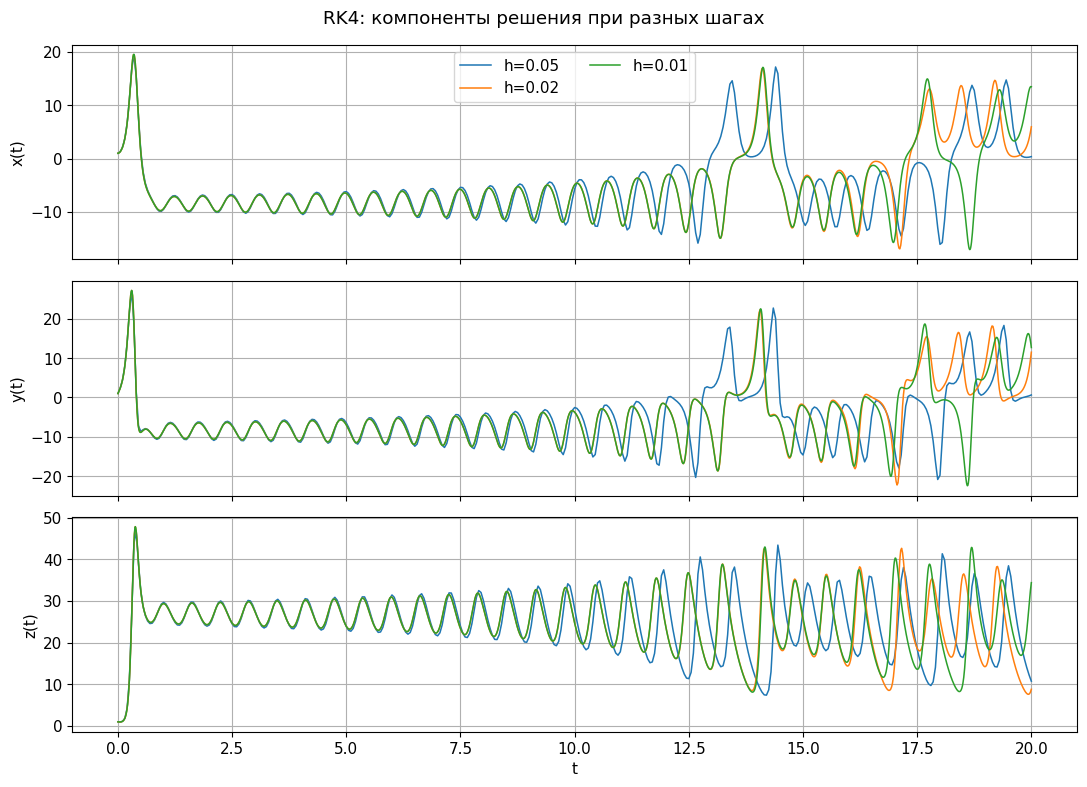

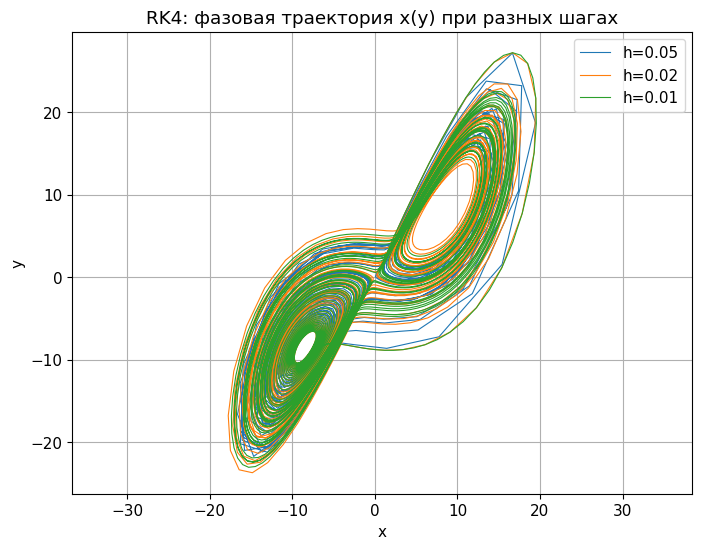

In [4]:
def finite_prefix(t, y):
    mask = np.all(np.isfinite(y), axis=1)
    if mask.all():
        return t, y
    last = np.argmax(~mask)
    return t[:last], y[:last]


def plot_time_components(results, title, t_max=20):
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
    names = ["x(t)", "y(t)", "z(t)"]
    for ax, idx, name in zip(axes, range(3), names):
        for label, (t, y) in results.items():
            tt, yy = finite_prefix(t, y)
            keep = tt <= t_max
            ax.plot(tt[keep], yy[keep, idx], lw=1.1, label=label)
        ax.set_ylabel(name)
    axes[-1].set_xlabel("t")
    axes[0].legend(ncol=2)
    fig.suptitle(title)
    fig.tight_layout()


def plot_phase_xy(results, title):
    plt.figure(figsize=(8, 6))
    for label, (t, y) in results.items():
        tt, yy = finite_prefix(t, y)
        plt.plot(yy[:, 0], yy[:, 1], lw=0.8, label=label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.axis("equal")


steps = [0.05, 0.02, 0.01]
rk4_by_step = {f"h={h:g}": integrate_rk(lorenz, Y0, T_END, h, 4) for h in steps}
ab4_by_step = {f"h={h:g}": integrate_ab(lorenz, Y0, T_END, h, 4) for h in steps}

plot_time_components(rk4_by_step, "RK4: компоненты решения при разных шагах", t_max=20)
plot_phase_xy(rk4_by_step, "RK4: фазовая траектория x(y) при разных шагах")

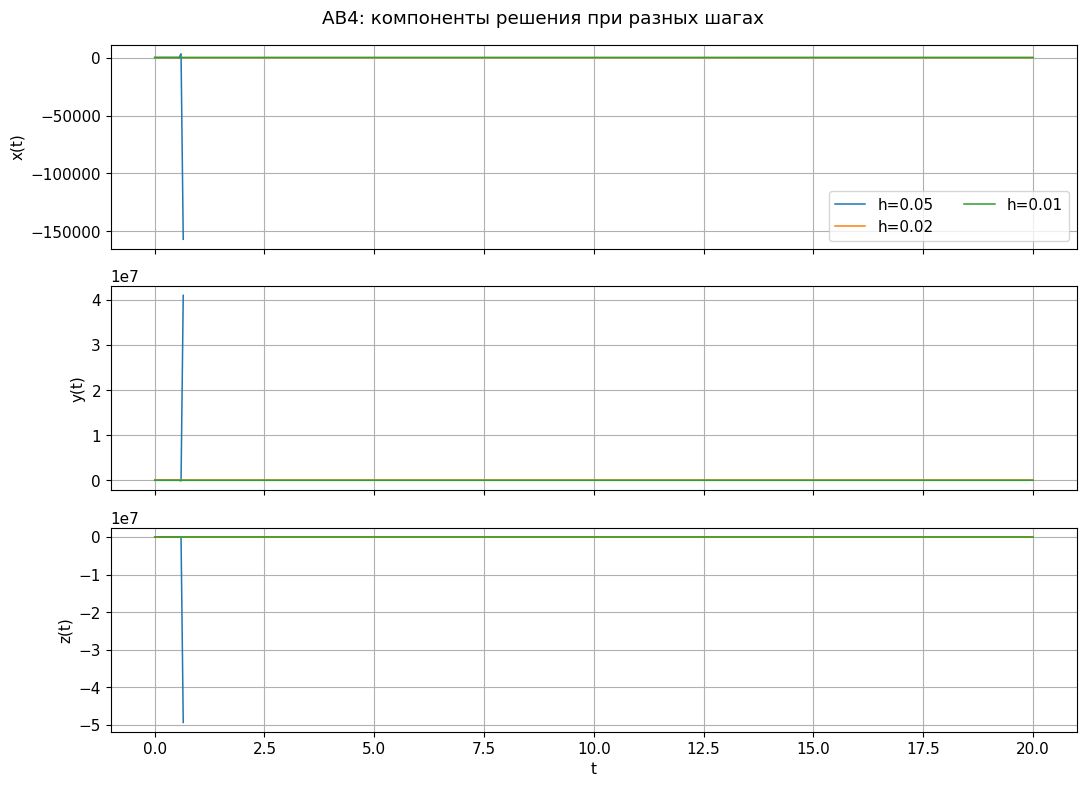

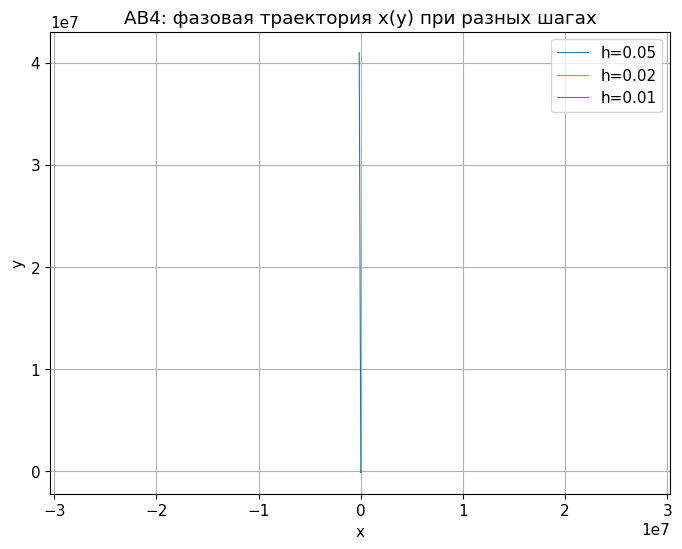

In [5]:
plot_time_components(ab4_by_step, "AB4: компоненты решения при разных шагах", t_max=20)
plot_phase_xy(ab4_by_step, "AB4: фазовая траектория x(y) при разных шагах")

### Сравнение порядков методов

Далее фиксируем шаг $h=0.01$ и сравниваем порядки 1--4. На таком шаге низкие порядки уже дают заметные фазовые расхождения, но расчет остается ограниченным. Для наглядности временные графики строятся на начальном участке $0\le t\le 15$, где поточечное сравнение еще имеет смысл.

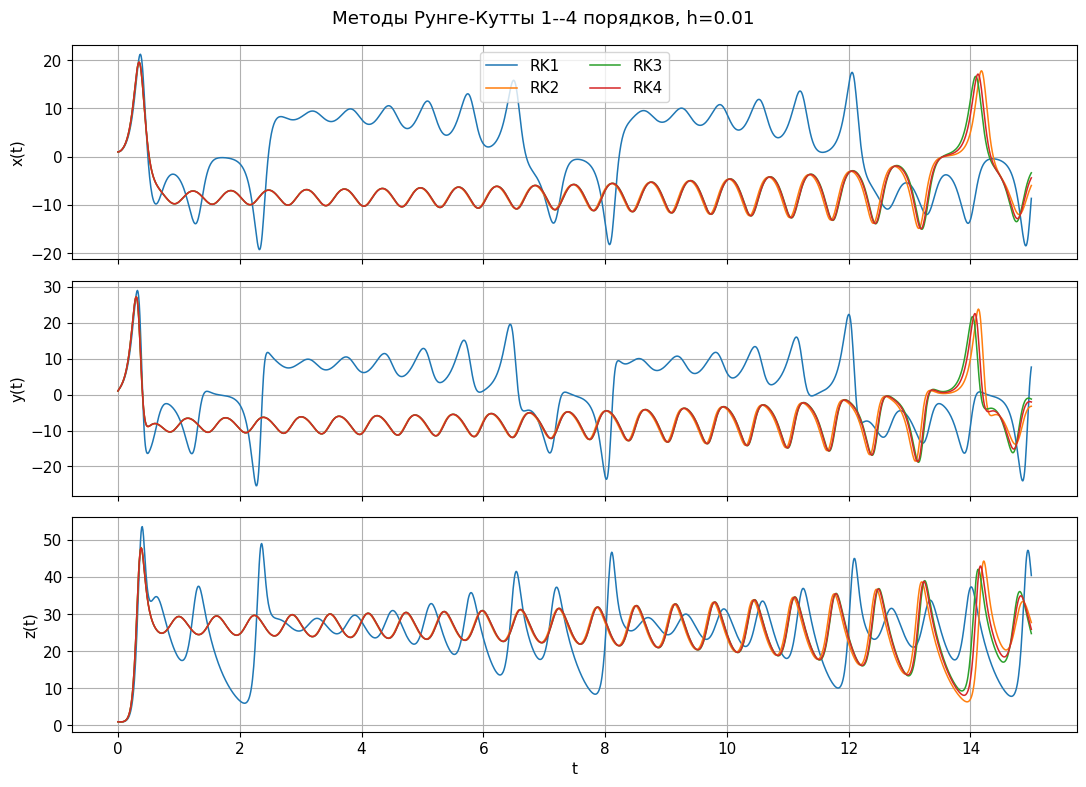

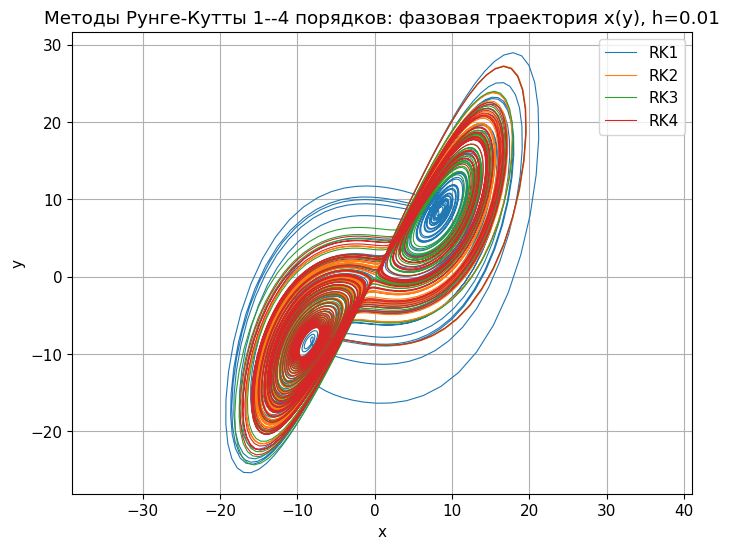

In [6]:
h = 0.01
rk_by_order = {f"RK{p}": integrate_rk(lorenz, Y0, T_END, h, p) for p in range(1, 5)}
ab_by_order = {f"AB{p}": integrate_ab(lorenz, Y0, T_END, h, p) for p in range(1, 5)}

plot_time_components(rk_by_order, "Методы Рунге-Кутты 1--4 порядков, h=0.01", t_max=15)
plot_phase_xy(rk_by_order, "Методы Рунге-Кутты 1--4 порядков: фазовая траектория x(y), h=0.01")

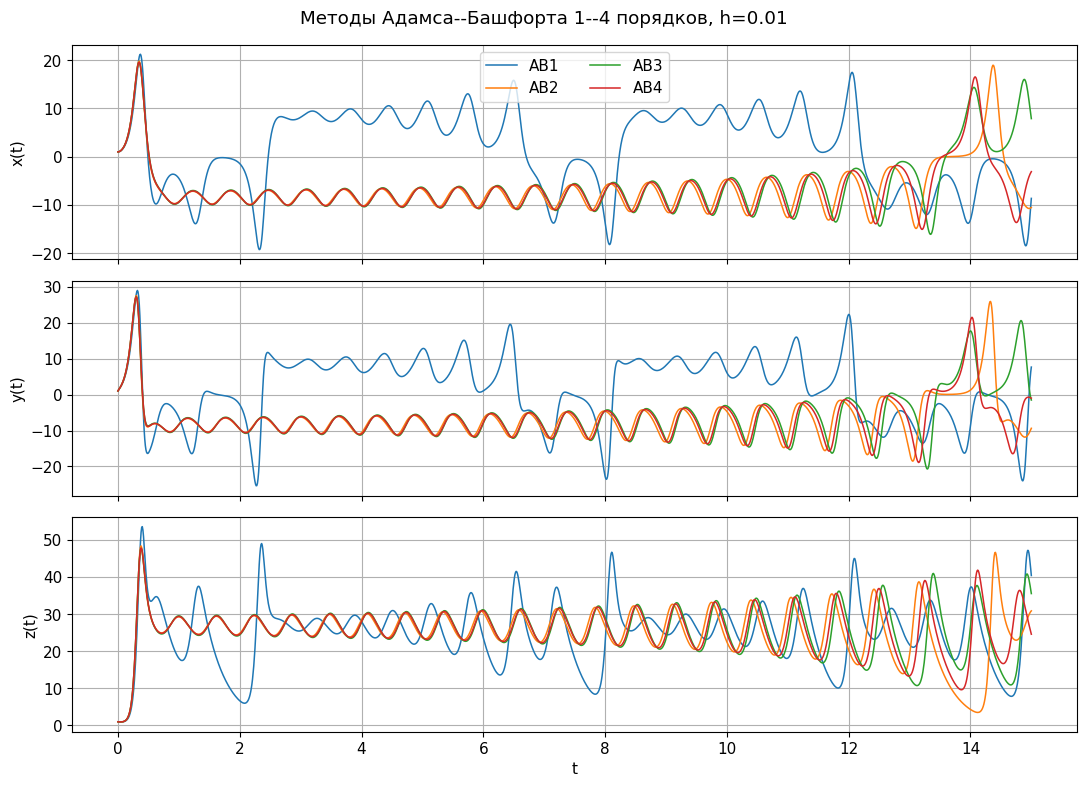

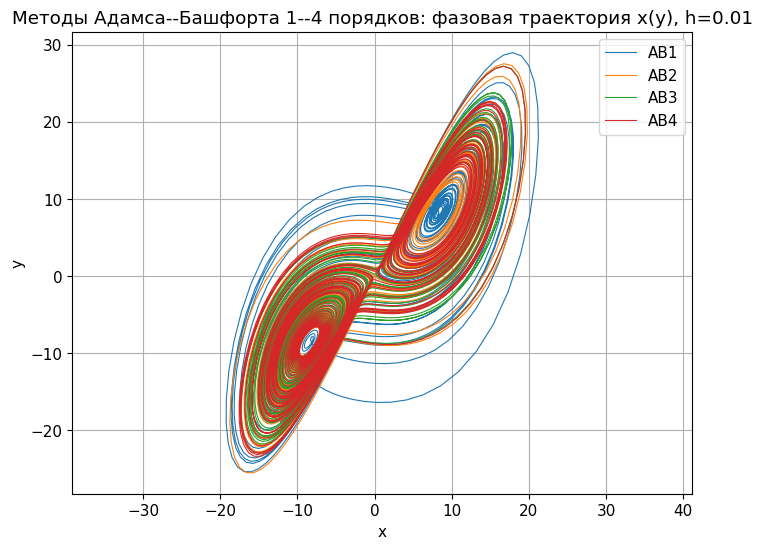

In [7]:
plot_time_components(ab_by_order, "Методы Адамса--Башфорта 1--4 порядков, h=0.01", t_max=15)
plot_phase_xy(ab_by_order, "Методы Адамса--Башфорта 1--4 порядков: фазовая траектория x(y), h=0.01")

### Трехмерная фазовая траектория

Для финальной иллюстрации построим трехмерный аттрактор по методу RK4 с шагом $h=0.01$.

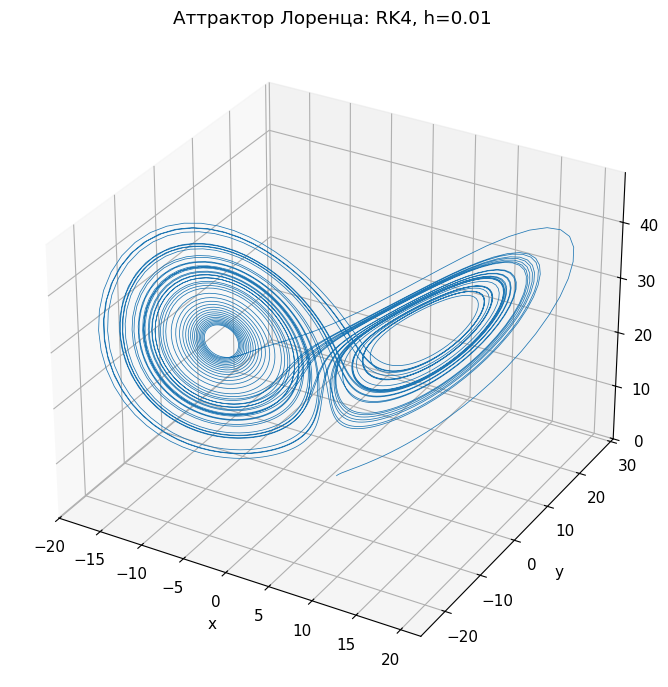

In [8]:
t_rk4, y_rk4 = rk_by_order["RK4"]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(y_rk4[:, 0], y_rk4[:, 1], y_rk4[:, 2], lw=0.55)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Аттрактор Лоренца: RK4, h=0.01")
plt.tight_layout()

## Сравнение с референсом

Поточечная ошибка считается относительно `solve_ivp(DOP853)`. Для хаотической системы ожидается, что ошибка быстро растет со временем даже у хороших методов: это отражает чувствительность системы, а не только локальную ошибку метода.

In [9]:
def max_error_against_reference(t, y, t_max):
    tt, yy = finite_prefix(t, y)
    keep = tt <= t_max
    ref = reference.sol(tt[keep]).T
    err = np.linalg.norm(yy[keep] - ref, axis=1)
    return float(np.max(err))


rows = []
for family, integrator in [("RK", integrate_rk), ("AB", integrate_ab)]:
    for order in range(1, 5):
        for h in [0.02, 0.01, 0.005]:
            t, y = integrator(lorenz, Y0, T_END, h, order)
            rows.append({
                "method": f"{family}{order}",
                "h": h,
                "max_err_t<=5": max_error_against_reference(t, y, 5.0),
                "max_err_t<=10": max_error_against_reference(t, y, 10.0),
                "finite_to": finite_prefix(t, y)[0][-1],
            })

print(f"{'method':<8} {'h':>8} {'max err, t<=5':>16} {'max err, t<=10':>18} {'finite to':>10}")
for row in rows:
    print(
        f"{row['method']:<8} {row['h']:>8.3g} "
        f"{row['max_err_t<=5']:>16.3e} {row['max_err_t<=10']:>18.3e} "
        f"{row['finite_to']:>10.2f}"
    )

method          h    max err, t<=5     max err, t<=10  finite to
RK1          0.02        3.749e+01          3.968e+01      50.00
RK1          0.01        2.706e+01          4.007e+01      50.00
RK1         0.005        1.246e+01          4.075e+01      50.00
RK2          0.02        1.668e+00          8.114e+00      50.00
RK2          0.01        3.696e-01          1.729e+00      50.00
RK2         0.005        8.206e-02          3.430e-01      50.00
RK3          0.02        2.964e-01          1.806e+00      50.00
RK3          0.01        4.087e-02          2.482e-01      50.00
RK3         0.005        5.243e-03          3.174e-02      50.00
RK4          0.02        1.290e-02          6.359e-02      50.00
RK4          0.01        7.982e-04          1.919e-03      50.00
RK4         0.005        4.949e-05          5.395e-05      50.00
AB1          0.02        3.749e+01          3.968e+01      50.00
AB1          0.01        2.706e+01          4.007e+01      50.00
AB1         0.005        

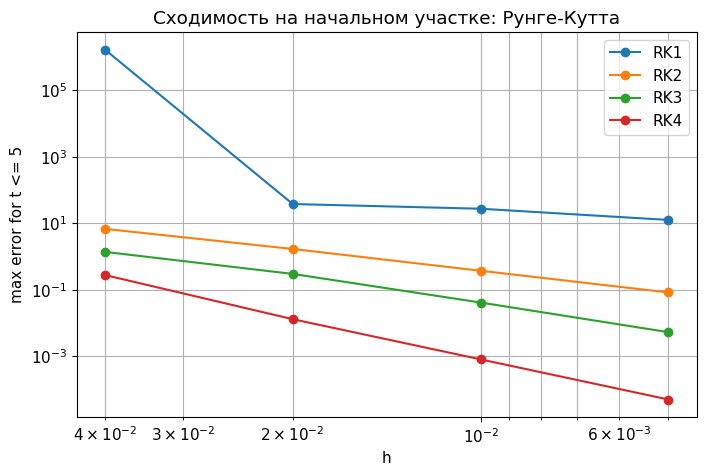

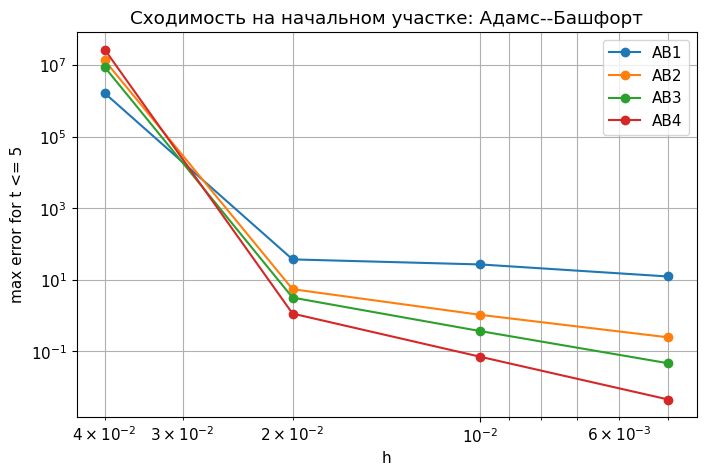

In [10]:
def collect_errors(integrator, prefix, t_max):
    hs = np.array([0.04, 0.02, 0.01, 0.005])
    data = {}
    for order in range(1, 5):
        errors = []
        for h in hs:
            t, y = integrator(lorenz, Y0, T_END, h, order)
            errors.append(max_error_against_reference(t, y, t_max))
        data[f"{prefix}{order}"] = np.array(errors)
    return hs, data


for integrator, prefix, title in [
    (integrate_rk, "RK", "Рунге-Кутта"),
    (integrate_ab, "AB", "Адамс--Башфорт"),
]:
    hs, data = collect_errors(integrator, prefix, t_max=5.0)
    plt.figure(figsize=(8, 5))
    for label, errors in data.items():
        plt.loglog(hs, errors, marker="o", label=label)
    plt.gca().invert_xaxis()
    plt.xlabel("h")
    plt.ylabel("max error for t <= 5")
    plt.title(f"Сходимость на начальном участке: {title}")
    plt.legend()
    plt.grid(True, which="both")
    plt.show()

## Особенности решения

1. Система Лоренца при заданных параметрах не является жесткой в типичном смысле, но она хаотична. Поэтому метод может быть локально точным, однако после некоторого времени его траектория уйдет в другую фазу относительно референса.
2. Методы первого порядка требуют существенно меньшего шага для сопоставимой точности. При $h=0.01$ они сохраняют общий характер движения, но заметно хуже совпадают с референсом на начальном участке.
3. Методы четвертого порядка дают лучшую точность при одинаковом шаге. RK4 обычно ведет себя устойчивее AB4, потому что одношаговая схема не использует накопленную историю правых частей.
4. Многошаговые методы Адамса--Башфорта чувствительны к стартовым значениям. В расчетах первые точки для AB2--AB4 получены RK4, иначе ошибка запуска могла бы исказить сравнение.
5. Фазовые портреты информативнее поточечного сравнения на длинном интервале: даже когда $x(t),y(t),z(t)$ расходятся по фазе, траектория должна оставаться на характерном двухлепестковом аттракторе.

## Вывод

В работе реализованы явные методы Рунге-Кутты и Адамса--Башфорта порядков 1--4 для системы Лоренца. Построены интегральные кривые компонент $x(t)$, $y(t)$, $z(t)$ и фазовые траектории для разных шагов и порядков методов.

Сравнение с высокоточным референсом показывает ожидаемое уменьшение ошибки при уменьшении шага на начальном участке. Для длинного интервала $0\le t\le 50$ поточечные траектории расходятся из-за хаотичности системы, поэтому основным качественным критерием становится сохранение ограниченного движения на аттракторе Лоренца. Наиболее надежные результаты среди рассмотренных вариантов дает RK4 с шагами $h=0.01$ и меньше; AB4 также воспроизводит структуру аттрактора, но сильнее зависит от качества стартовых точек и выбранного шага.